<a href="https://colab.research.google.com/github/Catheria29/MaRAI/blob/main/MaRAI_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
from google.colab import files

# 1. Set seed for consistency
np.random.seed(42)
n_rows = 1500

# 2. Generate features
age = np.random.randint(15, 55, n_rows)
systolic = np.random.randint(90, 160, n_rows)
diastolic = np.random.randint(60, 100, n_rows)
bs = np.random.uniform(6.0, 19.0, n_rows)
temp = np.random.uniform(98.0, 103.0, n_rows)
heart_rate = np.random.randint(60, 100, n_rows)

# 3. Create "Smart" Logic for RiskLevel (so the AI can actually learn)
risk_levels = []
for i in range(n_rows):
    # Logic: High blood sugar or high blood pressure = High Risk
    if bs[i] > 12 or systolic[i] > 140:
        risk_levels.append('high risk')
    elif bs[i] > 8 or systolic[i] > 125:
        risk_levels.append('mid risk')
    else:
        risk_levels.append('low risk')

# 4. Build the DataFrame
data_dict = {
    'Age': age,
    'SystolicBP': systolic,
    'DiastolicBP': diastolic,
    'BS': bs,
    'BodyTemp': temp,
    'HeartRate': heart_rate,
    'RiskLevel': risk_levels
}

df_final = pd.DataFrame(data_dict)

# 5. Save and Download
df_final.to_csv('Maternal_Health_Risk_Data_Set_1500.csv', index=False)
files.download('Maternal_Health_Risk_Data_Set_1500.csv')

print(f"✅ Created {len(df_final)} rows of Smart Synthetic Data!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Created 1500 rows of Smart Synthetic Data!


In [19]:
import pandas as pd

# 1. Load the data
# I am assuming you have a file named 'maternal_health.csv'
data = pd.read_csv('Maternal_Health_Risk_Data_Set_1500.csv')

# 2. Look at the first 5 rows to understand what we are dealing with
print(data.head())

   Age  SystolicBP  DiastolicBP         BS    BodyTemp  HeartRate  RiskLevel
0   53         147           94  10.447399  100.748586         93  high risk
1   43         115           61  11.589449  100.085821         68   mid risk
2   29         135           99  16.802339  102.388747         92  high risk
3   22         118           82   7.558584   99.019973         65   low risk
4   35          93           68  15.554036  102.132323         96  high risk


In [20]:
# Load the data we just saved
data = pd.read_csv('Maternal_Health_Risk_Data_Set_1500.csv')

# Map the text labels to numbers
risk_map = {'low risk': 0, 'mid risk': 1, 'high risk': 2}
data['RiskLevel'] = data['RiskLevel'].map(risk_map)

# Show the first 5 rows to make sure it worked
data.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,53,147,94,10.447399,100.748586,93,2
1,43,115,61,11.589449,100.085821,68,1
2,29,135,99,16.802339,102.388747,92,2
3,22,118,82,7.558584,99.019973,65,0
4,35,93,68,15.554036,102.132323,96,2


In [21]:
from sklearn.model_selection import train_test_split

# X = Clues (Age, Blood Pressure, etc.)
# y = Target (Risk Level)
X = data.drop('RiskLevel', axis=1)
y = data['RiskLevel']

# Step 1: Split into 80% (Temporary) and 20% (Final Test Exam)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Split the 80% (Temporary) into 75% Training and 25% Validation
# Note: 25% of 80% is exactly 20% of the original total!
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"📖 Training Set (Textbook): {len(X_train)} rows")
print(f"📝 Validation Set (Quiz): {len(X_val)} rows")
print(f"🎓 Test Set (Final Exam): {len(X_test)} rows")

📖 Training Set (Textbook): 900 rows
📝 Validation Set (Quiz): 300 rows
🎓 Test Set (Final Exam): 300 rows


In [22]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Random Forest 'Brain'
# n_estimators=100 means we are asking 100 'Decision Trees' to vote on the risk
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Start the Learning Process (Training)
# We give it the 'Clues' (X_train) and the 'Correct Answers' (y_train)
model.fit(X_train, y_train)

# 3. Take the Practice Quiz (Validation)
val_accuracy = model.score(X_val, y_val)

print(f"📊 Practice Quiz (Validation) Accuracy: {val_accuracy * 100:.2f}%")

📊 Practice Quiz (Validation) Accuracy: 99.67%


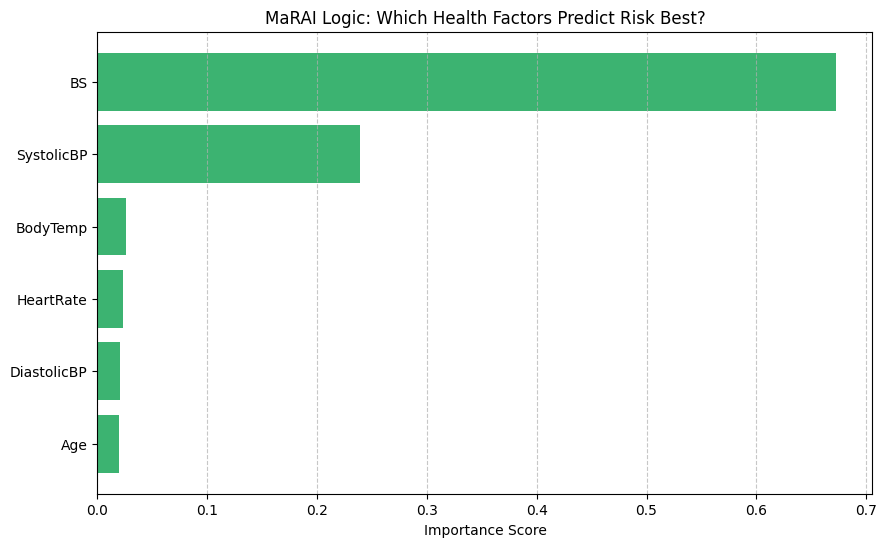

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the 'knowledge' from the forest
importances = model.feature_importances_
feature_names = X.columns

# 2. Sort them so the most important is at the top
indices = np.argsort(importances)

# 3. Create a professional chart for your portfolio
plt.figure(figsize=(10, 6))
plt.title("MaRAI Logic: Which Health Factors Predict Risk Best?")
plt.barh(range(len(indices)), importances[indices], color='mediumseagreen', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Importance Score")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

<Figure size 800x600 with 0 Axes>

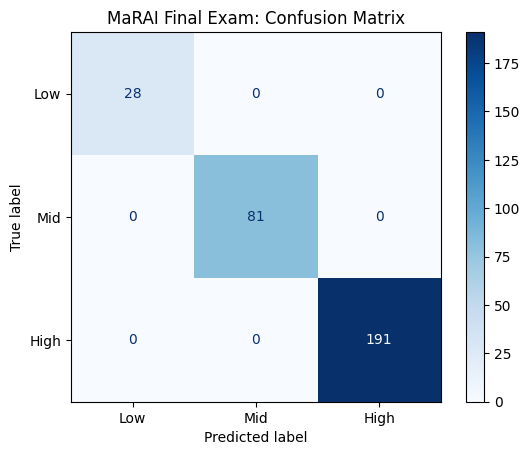

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. The AI takes the exam
y_pred = model.predict(X_test)

# 2. Compare the AI's answers (y_pred) to the True answers (y_test)
cm = confusion_matrix(y_test, y_pred)

# 3. Visualize the results
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Mid', 'High'])
disp.plot(cmap='Blues', values_format='d')
plt.title("MaRAI Final Exam: Confusion Matrix")
plt.show()

In [25]:
import pickle
from google.colab import files

# 1. 'Pickle' the model (Save the brain to a file)
# 'wb' means 'write binary'
with open('marai_model.pkl', 'wb') as file:
    pickle.dump(model, file)

# 2. Download it to your computer
files.download('marai_model.pkl')

print("✅ The MaRAI brain has been saved and downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ The MaRAI brain has been saved and downloaded!


In [27]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 53.8 MB/s eta 0:00:00


In [29]:

%%writefile app.py
import streamlit as st
import pickle
import numpy as np


# (Include all the polished UI code I gave you earlier here...)

# 1. Page Configuration (The 'Dress Up' part)
st.set_page_config(page_title="MaRAI: Maternal Health", layout="wide")

# 2. Load the Brain (Unpickling)
@st.cache_resource # This keeps the model in memory so it doesn't reload every time
def load_model():
    with open('marai_model.pkl', 'rb') as file:
        return pickle.load(file)

model = load_model()

# 3. Header Section
st.title("👩‍⚕️ MaRAI: Smart Pregnancy Planning Tool")
st.markdown("---")

# 4. Input Section (Using Columns for a better UI)
st.subheader("Patient Vitals")
col1, col2, col3 = st.columns(3)

with col1:
    age = st.number_input("Age", min_value=15, max_value=55, value=25)
    heart_rate = st.number_input("Heart Rate (bpm)", min_value=60, max_value=100, value=70)

with col2:
    systolic = st.number_input("Systolic BP", min_value=90, max_value=160, value=120)
    diastolic = st.number_input("Diastolic BP", min_value=60, max_value=100, value=80)

with col3:
    bs = st.number_input("Blood Sugar (BS)", min_value=6.0, max_value=19.0, value=7.0)
    temp = st.number_input("Body Temperature (F)", min_value=98.0, max_value=103.0, value=98.6)

# 5. Prediction Logic
st.markdown("###") # Adds some space
if st.button("Analyze Risk Level", use_container_width=True):
    # Prepare the data in the same order the model studied it
    features = np.array([[age, systolic, diastolic, bs, temp, heart_rate]])

    # Get the numeric prediction
    prediction = model.predict(features)[0]

    # Map back to text and colors
    risk_labels = {0: "Low Risk", 1: "Mid Risk", 2: "High Risk"}
    risk_colors = {0: "success", 1: "warning", 2: "error"} # Streamlit alert colors

    result = risk_labels[prediction]

    # 6. Display the Result
    st.markdown("---")
    st.header(f"Result: {result}")

    if prediction == 2:
        st.error("⚠️ This patient is classified as HIGH RISK. Immediate medical consultation is advised.")
    elif prediction == 1:
        st.warning("🟡 This patient is at MID RISK. Frequent monitoring is recommended.")
    else:
        st.success("✅ This patient is currently at LOW RISK.")

Writing app.py


In [ ]:
# 1. Install localtunnel
!npm install -g localtunnel

# 2. Run streamlit in the background
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
changed 22 packages in 2s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇⠙

⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧your url is: https://six-carpets-greet.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.50.173.73:8501

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [31]:
!curl ipv4.icanhazip.com

34.50.173.73
